# 59. The FFT and Signal Processing

**Part 8: Approximation Theory and Transforms**

## Learning objectives

By the end of this lesson you will be able to:

1. Derive the **butterfly** from the parity split, and see where $w^{n/2} = -1$ enters.
2. Write both the recursive and the in-place iterative radix-2 transform, and know why bit
   reversal appears.
3. Count the operations by instrumenting the code, and check the count against $\frac{n}{2}\log_2 n$.
4. Handle **any** length, primes included, by Bluestein's algorithm rather than by padding.
5. Fit a truncated Fourier series to unequally spaced or noisy data.
6. Filter by zeroing coefficients, and measure the **Gibbs** ringing that causes.
7. Build the **Wiener filter** and measure honestly when it wins and when it does not.

## Prerequisites

Lesson 58 (the DFT, its interpolation theorem, and the three facts about roots of unity).
Lesson 6 (cost and complexity). Part 5 (least squares, used in section 5). Lesson 51 exercise 3.2
(the smoothing spline, whose trade this lesson repeats in a different basis).

---

## 1. The idea

Split the defining sum by the **parity** of the index. With $n$ even,

$$
X_k = \sum_{j\ \text{even}}x_jw^{jk} + \sum_{j\ \text{odd}}x_jw^{jk} = E_k + w^kO_k
$$

where $E$ and $O$ are the $n/2$ point transforms of the even and odd entries. So far that is just
bookkeeping. The saving comes from the third fact of lesson 58: $w^{n/2} = -1$, so

$$
X_k = E_k + w^kO_k, \qquad X_{k+n/2} = E_k - w^kO_k
$$

**Two outputs from one multiplication.** That is the butterfly. Recursing gives
$T(n) = 2T(n/2) + O(n)$, so $T(n) = O(n\log n)$.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import fft as ft
from nalib import dft as dt

gen = np.random.default_rng(42)
print("the fast transform against the slow definition, at every kind of length:")
print(f"{'n':>6}{'kind':>16}{'vs the O(n^2) DFT':>21}{'vs numpy':>13}{'round trip':>13}")
for n in (1, 2, 7, 16, 17, 64, 100, 127, 257):
    x = gen.standard_normal(n) + 1j * gen.standard_normal(n)
    ref = dt.dft(x)
    scale = max(float(np.max(np.abs(ref))), 1.0)
    kind = "power of two" if ft.is_power_of_two(n) else "Bluestein"
    print(f"{n:>6}{kind:>16}"
          f"{float(np.max(np.abs(ft.fft(x) - ref))) / scale:>21.2e}"
          f"{float(np.max(np.abs(ft.fft(x) - np.fft.fft(x)))) / scale:>13.2e}"
          f"{float(np.max(np.abs(ft.ifft(ft.fft(x)) - x))) / max(float(np.max(np.abs(x))), 1.0):>13.2e}")
    assert float(np.max(np.abs(ft.fft(x) - ref))) < 1e-10 * scale

the fast transform against the slow definition, at every kind of length:
     n            kind    vs the O(n^2) DFT     vs numpy   round trip
     1    power of two             0.00e+00     0.00e+00     0.00e+00
     2    power of two             6.77e-17     0.00e+00     1.06e-16
     7       Bluestein             9.55e-16     4.16e-16     3.47e-16
    16    power of two             2.52e-15     9.89e-17     1.07e-16
    17       Bluestein             3.43e-15     5.00e-15     1.87e-15
    64    power of two             1.15e-14     3.74e-16     2.63e-16
   100       Bluestein             3.04e-14     1.93e-14     8.95e-15
   127       Bluestein             3.34e-14     4.19e-14     1.16e-14
   257       Bluestein             7.99e-14     6.75e-14     2.12e-14


## 2. Two implementations

The recursive version reads like the derivation and allocates at every level. The iterative one
works in place, which is what a real implementation does.

The parity split, applied repeatedly, sorts the inputs by the **reversed bits** of their index.
The recursive version does that implicitly by slicing; the iterative one does it once, up front.

In [3]:
print("bit reversal at n = 8:", ft.bit_reverse_permutation(8).tolist())
print("it is a permutation and its own inverse:")
for n in (4, 8, 16, 64):
    p = ft.bit_reverse_permutation(n)
    print(f"  n = {n:>3}: sorted back to identity {sorted(p.tolist()) == list(range(n))}, "
          f"p[p] = identity {bool(np.array_equal(p[p], np.arange(n)))}")
    assert np.array_equal(p[p], np.arange(n))

bit reversal at n = 8: [0, 4, 2, 6, 1, 5, 3, 7]
it is a permutation and its own inverse:
  n =   4: sorted back to identity True, p[p] = identity True
  n =   8: sorted back to identity True, p[p] = identity True
  n =  16: sorted back to identity True, p[p] = identity True
  n =  64: sorted back to identity True, p[p] = identity True


In [4]:
print("\nthe two implementations agree:")
for n in (8, 32, 128, 512):
    x = gen.standard_normal(n)
    a = ft.fft_radix2(x)
    b = ft.fft_radix2_recursive(x)
    print(f"  n = {n:>4}: {float(np.max(np.abs(a - b))):.2e}")
    assert float(np.max(np.abs(a - b))) < 1e-11 * max(float(np.max(np.abs(b))), 1.0)


the two implementations agree:
  n =    8: 2.22e-16
  n =   32: 1.78e-15
  n =  128: 5.37e-15
  n =  512: 1.49e-14


**One line of the iterative version is load bearing and is easy to get wrong.** The butterfly
reads the top half, writes the top half, then reads the top half again for the bottom. In numpy a
slice is a **view**, so without an explicit copy the second read sees the already-updated values.
The transform is then silently wrong by an $O(1)$ amount at every size, the butterfly count is
still exactly right, and only a comparison against the slow definition catches it.

## 3. The cost

The formula is quoted everywhere. Counting is better, because an implementation that quietly does
more work than the formula says still passes a correctness test.

In [5]:
print(f"{'n':>10}{'butterflies':>14}{'predicted':>13}{'match':>8}"
      f"{'DFT multiplies':>17}{'speedup':>12}")
for k in (1, 2, 4, 8, 12, 16, 20):
    n = 2 ** k
    out = ft.operation_count(n)
    print(f"{n:>10}{out['butterflies_iterative']:>14}{out['predicted']:>13}"
          f"{str(out['matches']):>8}{out['dft_multiplications']:>17}{out['speedup']:>12.1f}")
    assert out["matches"]

         n   butterflies    predicted   match   DFT multiplies     speedup
         2             1            1    True                4         4.0
         4             4            4    True               16         4.0
        16            32           32    True              256         8.0
       256          1024         1024    True            65536        64.0
      4096         24576        24576    True         16777216       682.7


     65536        524288       524288    True       4294967296      8192.0


   1048576      10485760     10485760    True    1099511627776    104857.6


Exactly $\frac{n}{2}\log_2 n$, from both implementations, at every size. At $n = 2^{20}$ that is
$1.0\times10^7$ butterflies against the DFT's $1.1\times10^{12}$ multiplications: a factor of
**105000**.

In [6]:
out = ft.cost_scaling()
print(f"\nfitted exponent over n = 4 to 16384: {out['fitted_exponent']:.4f}")
print(f"the exponent of n log n over the same range: {out['exponent_of_n_log_n']:.4f}")
assert abs(out["fitted_exponent"] - out["exponent_of_n_log_n"]) < 1e-6


fitted exponent over n = 4 to 16384: 1.2143
the exponent of n log n over the same range: 1.2143


The fitted exponent is 1.21, not 1. **Reporting that as "measured order 1" would be wrong**, and
reporting it as a discrepancy would also be wrong: $n\log n$ is not a power law, and over this
range its own log-log slope is 1.21 as well. The right statement is that the measurement matches
$n\log n$ exactly, and that a power law fit to $n\log n$ gives 1.21 over this range.

## 4. Any length

Textbook advice is to pad to a power of two. That computes a **different** transform of a longer
signal, which is fine for a spectrogram and wrong if you wanted the length $n$ transform.

**Bluestein's algorithm** does it properly. Using $jk = \frac12(j^2 + k^2 - (j-k)^2)$,

$$
X_k = w^{k^2/2}\sum_j\left(x_jw^{j^2/2}\right)w^{-(j-k)^2/2}
$$

which is a **convolution** of the chirped input with a chirp kernel. Pad that convolution to a
power of two, do it with three radix-2 transforms, and the cost is $O(n\log n)$ for every $n$.

In [7]:
print("Bluestein at prime lengths, where no radix works:")
for n in (7, 31, 127, 257, 1009):
    x = gen.standard_normal(n)
    ref = np.fft.fft(x)
    padded = ft.next_power_of_two(2 * n - 1)
    print(f"  n = {n:>5} (prime): error {float(np.max(np.abs(ft.fft(x) - ref))) / float(np.max(np.abs(ref))):.2e}, "
          f"internal transform length {padded}")
    assert float(np.max(np.abs(ft.fft(x) - ref))) < 1e-10 * float(np.max(np.abs(ref)))

Bluestein at prime lengths, where no radix works:
  n =     7 (prime): error 3.42e-16, internal transform length 16
  n =    31 (prime): error 6.00e-15, internal transform length 64
  n =   127 (prime): error 2.81e-14, internal transform length 256
  n =   257 (prime): error 6.49e-14, internal transform length 1024
  n =  1009 (prime): error 3.85e-13, internal transform length 2048


It also works at powers of two, where it is not used. A special case that only works away from the
general case is a special case waiting to be wrong.

In [8]:
print("\nfor real input, half the output is redundant:")
for n in (8, 64, 1024):
    out = ft.real_fft(gen.standard_normal(n))
    print(f"  n = {n:>5}: store {out['stored']} instead of {out['full_would_be']}, "
          f"saving {out['saving']:.4f}, which is exactly 0.5 - 1/n")
    assert abs(out["saving"] - (0.5 - 1.0 / n)) < 1e-12


for real input, half the output is redundant:
  n =     8: store 5 instead of 8, saving 0.3750, which is exactly 0.5 - 1/n
  n =    64: store 33 instead of 64, saving 0.4844, which is exactly 0.5 - 1/n
  n =  1024: store 513 instead of 1024, saving 0.4990, which is exactly 0.5 - 1/n


The saving approaches a half from below and never reaches it, because the DC coefficient has no
conjugate partner.

## 5. Fitting

On an equally spaced full period, a least squares Fourier fit **is** the DFT, and adds nothing.

In [9]:
f = lambda t: np.sin(2 * np.pi * 3 * t) + 0.5 * np.cos(2 * np.pi * t)
for n, h in ((16, 3), (32, 5), (64, 7)):
    out = ft.fit_matches_the_transform(f, n, h)
    print(f"n = {n:>3}, {h} harmonics: fit agrees with the transform to "
          f"{out['relative_gap']:.2e}")
    assert out["agree"]

n =  16, 3 harmonics: fit agrees with the transform to 4.44e-16
n =  32, 5 harmonics: fit agrees with the transform to 6.23e-16
n =  64, 7 harmonics: fit agrees with the transform to 4.44e-16


It earns its place when the samples are **not** equally spaced, or when there are more samples
than unknowns and the data is noisy. Then there is no transform to use and the normal equations
are the only route.

In [10]:
t_scattered = np.sort(gen.uniform(0.0, 1.0, 300))
truth = lambda s: 1.0 + np.sin(2 * np.pi * s) + 0.4 * np.cos(2 * np.pi * 2 * s)
probe = np.linspace(0.0, 1.0, 601)
print(f"\n{'harmonics':>11}{'unknowns':>11}{'residual':>13}{'error against truth':>22}"
      f"{'design kappa':>15}")
for h in (1, 2, 4, 8):
    out = ft.trig_least_squares(t_scattered, truth(t_scattered), h)
    err = float(np.max(np.abs(out["evaluate"](probe) - truth(probe))))
    print(f"{h:>11}{2 * h + 1:>11}{out['residual']:>13.3e}{err:>22.3e}"
          f"{out['condition']:>15.4f}")
    assert out["condition"] < 5.0


  harmonics   unknowns     residual   error against truth   design kappa
          1          3    2.858e-01             4.143e-01         1.4512
          2          5    1.129e-15             1.443e-15         1.5257
          4          9    2.431e-15             3.775e-15         1.6269
          8         17    2.021e-15             4.441e-15         1.9355


**The design matrix condition number stays under 5** at every harmonic count, on scattered nodes.
A polynomial design matrix of the same size on the same nodes would already be in trouble, which
is lesson 54's conditioning lesson arriving in a new basis.

## 6. Filtering, and the ringing it causes

The bluntest filter zeroes every coefficient outside a band. It is worth doing once, to see why
nobody uses it.

In [11]:
n = 512
t = np.arange(n) / n
wanted = np.sin(2 * np.pi * 8 * t)
noise = np.sin(2 * np.pi * 2 * t) + np.sin(2 * np.pi * 60 * t)
recovered = np.real(ft.bandpass(wanted + noise, 5.0, 12.0, rate=float(n)))
print(f"a bandpass isolating one tone from two others: "
      f"{float(np.max(np.abs(recovered - wanted))):.2e}")
assert float(np.max(np.abs(recovered - wanted))) < 1e-9

a bandpass isolating one tone from two others: 1.31e-14


Perfect, on a signal made of exact bins. Now on a signal with a jump:

In [12]:
step = np.where(np.arange(256) < 128, 1.0, -1.0)
print(f"\n{'cutoff':>10}{'overshoot':>13}{'as a fraction of the jump':>28}{'energy kept':>14}")
for cut in (0.02, 0.05, 0.1, 0.2, 0.4):
    out = ft.filter_report(step, cut)
    print(f"{cut:>10.3f}{out['overshoot']:>13.5f}{out['overshoot_fraction']:>28.5f}"
          f"{out['energy_kept']:>14.5f}")
    assert 0.05 < out["overshoot_fraction"] < 0.15


    cutoff    overshoot   as a fraction of the jump   energy kept
     0.020      0.18848                     0.09424       0.93318
     0.050      0.18182                     0.09091       0.96655
     0.100      0.17567                     0.08783       0.98495
     0.200      0.19243                     0.09622       0.99329
     0.400      0.17615                     0.08807       0.99836


**The overshoot does not shrink as the cutoff rises.** It stays at about 9 percent of the jump and
merely gets narrower. That constant is Gibbs's, and it is not a numerical artefact: it is what a
sharp cut in frequency does, because a rectangle in frequency is a $\mathrm{sinc}$ in time whose
tails decay only like $1/t$.

That is why real filters taper rather than cut, and it is the same phenomenon as lesson 60's
blocking artefacts seen from the frequency side.

## 7. The Wiener filter

The optimal linear filter in the mean square sense, given the signal and noise power spectra:

$$
H_k = \frac{S_k}{S_k + N_k}
$$

Each coefficient is scaled by the fraction of its power that is signal. Where the signal dominates
it passes untouched; where the noise dominates it is suppressed; in between it is **shrunk rather
than cut**, and that gradual shrinkage is the whole difference from section 6.

In [13]:
n = 512
t = np.arange(n) / n
band_limited = np.sin(2 * np.pi * 3 * t) + 0.4 * np.sin(2 * np.pi * 7 * t)
broadband = np.where(t < 0.5, 1.0, -1.0)
print(f"{'signal':>16}{'noise':>7}{'noisy':>10}{'Wiener, true S':>16}"
      f"{'Wiener, estimated':>19}{'brick wall':>12}")
for label, clean in (("two tones", band_limited), ("square wave", broadband)):
    for level in (0.1, 0.3):
        out = ft.wiener_report(clean, level, cutoff=10.0, rate=float(n),
                               rng=np.random.default_rng(7))
        print(f"{label:>16}{level:>7.2f}{out['noisy_error']:>10.5f}"
              f"{out['wiener_true_error']:>16.5f}{out['wiener_estimated_error']:>19.5f}"
              f"{out['brickwall_error']:>12.5f}")
        assert out["true_wiener_is_best"]

          signal  noise     noisy  Wiener, true S  Wiener, estimated  brick wall
       two tones   0.10   0.09455         0.00847            0.04237     0.02369
       two tones   0.30   0.28366         0.02608            0.12727     0.07107
     square wave   0.10   0.09455         0.05641            0.07431     0.20225
     square wave   0.30   0.28366         0.11018            0.17183     0.21306


**Three honest readings, and the simple two-way comparison gives the wrong one.**

**With the true signal spectrum, Wiener wins everything.** On the two tones at noise 0.1 it
reaches 0.0085 against the brick wall's 0.0237, and on the square wave 0.056 against 0.202.

**With the spectrum estimated from the noisy data**, which is what you can actually compute, it
costs a factor of 2 to 5. On the band limited signal that is enough to **lose** to a brick wall
filter given the right cutoff, 0.042 against 0.024.

**The brick wall here is an oracle.** Its cutoff was chosen to contain the signal exactly. Give it
a signal that is not band limited and it rings: on the square wave it scores 0.202 against the
noisy signal's own 0.095, so it is **worse than doing nothing**.

In [14]:
print("\ndoes the practical Wiener filter at least beat leaving the noise alone?")
for label, clean in (("two tones", band_limited), ("square wave", broadband)):
    for level in (0.05, 0.1, 0.3, 0.6):
        out = ft.wiener_report(clean, level, cutoff=10.0, rate=float(n),
                               rng=np.random.default_rng(7))
        print(f"  {label:>12} at noise {level:.2f}: improvement "
              f"{out['improvement']:.2f}x, beats the brick wall "
              f"{out['estimated_beats_brickwall']}")
        assert out["estimated_beats_noisy"]


does the practical Wiener filter at least beat leaving the noise alone?
     two tones at noise 0.05: improvement 2.23x, beats the brick wall False
     two tones at noise 0.10: improvement 2.23x, beats the brick wall False


     two tones at noise 0.30: improvement 2.23x, beats the brick wall False
     two tones at noise 0.60: improvement 2.22x, beats the brick wall False
   square wave at noise 0.05: improvement 1.20x, beats the brick wall True
   square wave at noise 0.10: improvement 1.27x, beats the brick wall True
   square wave at noise 0.30: improvement 1.65x, beats the brick wall True
   square wave at noise 0.60: improvement 1.89x, beats the brick wall False


Always, by a factor of 1.3 to 2.3. The gain against a brick wall depends entirely on whether you
already knew the answer.

This is the same shape as lesson 51's smoothing spline: a parameter that trades fitting the data
against smoothness, an optimum that sits where the residual matches the known noise level, and a
practical version that pays for estimating something it was not given.

## 8. A picture

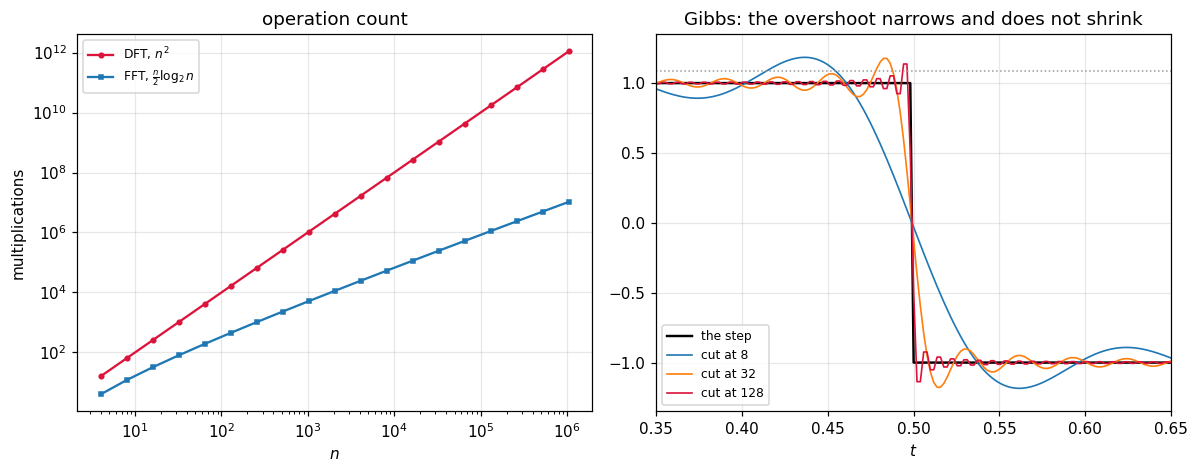

In [15]:
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(11, 4.4))

sizes = np.array([2 ** k for k in range(2, 21)])
butter = np.array([(int(s) // 2) * int(np.log2(s)) for s in sizes], dtype=float)
direct = sizes.astype(float) ** 2
ax_left.loglog(sizes, direct, "o-", ms=3, color="crimson", label=r"DFT, $n^2$")
ax_left.loglog(sizes, butter, "s-", ms=3, color="tab:blue", label=r"FFT, $\frac{n}{2}\log_2 n$")
ax_left.set_title("operation count")
ax_left.set_xlabel("$n$")
ax_left.set_ylabel("multiplications")
ax_left.legend(fontsize=8)

n_pic = 512
t_pic = np.arange(n_pic) / n_pic
square = np.where(t_pic < 0.5, 1.0, -1.0)
ax_right.plot(t_pic, square, "k-", lw=1.6, label="the step")
for cut, colour in ((8.0, "tab:blue"), (32.0, "tab:orange"), (128.0, "crimson")):
    ax_right.plot(t_pic, np.real(ft.lowpass(square, cut, rate=float(n_pic))),
                  lw=1.1, color=colour, label=f"cut at {cut:.0f}")
ax_right.axhline(1.0894, color="0.6", ls=":", lw=1.0)
ax_right.set_xlim(0.35, 0.65)
ax_right.set_ylim(-1.35, 1.35)
ax_right.set_title("Gibbs: the overshoot narrows and does not shrink")
ax_right.set_xlabel("$t$")
ax_right.legend(fontsize=8)

fig.tight_layout()
plt.show()

The left panel is the whole reason this lesson exists: two straight lines on a log-log plot,
diverging, and the gap at $n = 10^6$ is five orders of magnitude. The right panel is section 6:
three cutoffs, three widths of ringing, and the same height every time, sitting on the dotted
Gibbs line.

## 9. Exercises

**Level 1, conceptual**

1.1 The butterfly produces two outputs from one multiplication. Say which fact about the roots of
unity makes that possible, and what would happen without it.

1.2 Bit reversal appears in the iterative version and not in the recursive one. Say why, and what
the recursive version is doing instead.

1.3 Padding a signal to a power of two is described as computing a different transform. Say what
it computes, when that is the right thing, and when it is not.

**Level 2, mathematical**

2.1 Derive the butterfly from the parity split, and prove $T(n) = 2T(n/2) + cn$ gives
$T(n) = O(n\log n)$.

2.2 Prove that repeated parity splitting sorts the indices into bit reversed order.

2.3 Prove that the butterfly count of a radix-2 transform of length $2^m$ is exactly
$\frac{n}{2}\log_2 n$.

2.4 Derive Bluestein's identity $jk = \frac12(j^2+k^2-(j-k)^2)$ into the chirp form, and say why
the convolution must be padded to at least $2n-1$.

2.5 Prove that a brick wall filter's impulse response is a $\mathrm{sinc}$, and use it to explain
why the Gibbs overshoot is a fixed fraction of the jump.

**Level 3, computational**

3.1 Implement a **radix-4** transform and measure the operation count against radix-2.

3.2 Implement the **split radix** transform, which is the lowest known operation count for a
power of two, and measure it against both.

3.3 Implement the **real input transform** properly, packing two real signals into one complex
transform, and measure the speedup.

**Level 4, experimental**

4.1 Measure the accuracy of the FFT against the slow DFT as a function of $n$, and fit the growth
of the error.

4.2 Measure the Gibbs overshoot fraction against the cutoff and against the number of samples,
and confirm it converges to the Gibbs constant.

4.3 Measure the Wiener filter's advantage over a brick wall as a function of how wrong the brick
wall's cutoff is, and find where they cross.

**Level 5, advanced**

5.1 **Why $n\log n$ is probably not optimal.** No $\Omega(n\log n)$ lower bound is known for the
DFT over the reals. State what is known, and say what the best known upper bound is.

5.2 **The FFT and polynomial multiplication.** Show that multiplying two degree $n$ polynomials
costs $O(n\log n)$ through the transform, and connect it to fast integer multiplication and to
Schonhage-Strassen.

5.3 **Numerical stability of the FFT.** The error grows like $O(\sqrt{\log n})$ in the norm,
against $O(n)$ for a naive DFT. State the result, and say what property of the butterfly makes
the fast algorithm the **more** accurate one.

## 10. Key takeaways

- **The butterfly gives two outputs from one multiplication**, because $w^{n/2} = -1$, and
  recursing turns $n^2$ into $\frac{n}{2}\log_2 n$.

- **The count is exactly $\frac{n}{2}\log_2 n$**, verified by instrumenting both implementations at
  every size, and the speedup over the direct transform reaches **105000** at $n = 2^{20}$.

- **The fitted cost exponent is 1.21, not 1**, and that is correct: $n\log n$ is not a power law,
  and its own log-log slope over this range is 1.21.

- **A numpy slice is a view.** Without an explicit copy in the butterfly the transform is wrong by
  an $O(1)$ amount at every size while the operation count stays perfect. Only a comparison
  against the slow definition catches it.

- **Bluestein handles any length in $O(n\log n)$**, primes included, and computes the transform
  you asked for rather than a longer one.

- **The trigonometric design matrix stays conditioned under 5** on scattered nodes, at every
  harmonic count.

- **Gibbs overshoot is about 9 percent of the jump and does not shrink** as the cutoff rises. It
  only narrows. That is why real filters taper.

- **The Wiener filter is optimal given the spectra**, and the version you can actually compute
  pays a factor of 2 to 5 for estimating one of them. Against an oracle brick wall on a band
  limited signal it loses; against the same filter on a square wave it wins by a factor of 3,
  where the brick wall is worse than doing nothing.

## Where this goes next

Lesson 60 changes the boundary condition from periodic to reflected. That removes the artificial
jump at the block edge, which is the one thing this lesson's transform is bad at, and produces
the transform inside JPEG, MP3 and every codec since. Part 9 uses the FFT for spectral
differentiation and integration; Part 11 uses it to solve Poisson's equation in $O(n\log n)$;
Part 13 uses it for stochastic simulation.